# Asignación de Variedades a Anclas — Experimento de Clustering

| | |
|---|---|
| **Proyecto** | `ml_random_forest / ml_training` |
| **Propósito** | Decidir qué variedades se entrenan como modelo propio y cuáles heredan un ancla cercana |
| **Entrada** | `training/DB-HISTORICA.xlsx` (una hoja por variedad) |
| **Salida** | `variety_anchor_assignment.csv` · `variety_training_mapping.csv` · `variety_anchor_mapping.yaml` · `decision_table.csv` + `decision_table.html` |
| **Corre independiente de** | `modelo_nuevo_ml.ipynb` — el YAML generado aquí **alimenta** el entrenamiento |

---

## ¿Por qué existe este notebook?

Tenemos **37 variedades** de arándano, pero no todas tienen datos suficientes ni distribuciones propias como para justificar un modelo individual. Entrenar 37 modelos cuando 11 bastarían es caro, lento y genera modelos frágiles para las variedades con pocos datos.

Este notebook **decide con criterio estadístico** qué 11 variedades son **anclas** (entrenan su propio modelo) y a cuál ancla debe asignarse cada una de las 26 restantes para heredar su modelo.

### Decisión gerencial que responde

> ¿Cuántos modelos entreno y cuál cubre a cuál variedad, con sustento estadístico?

**Resultado típico:** 11 modelos entrenados · 37 variedades cubiertas · 3/4 tests globales pasan · análisis reforzado (bootstrap + Holm + Silhouette global) confirma robustez por variedad → agrupación con **sustento estadístico sólido y accionable**.

---

## Método (4 pasos + refuerzo)

| # | Paso | Técnica | ¿Para qué? |
|---|------|---------|-----------|
| 1 | Cargar datos y separar anclas | Lectura de Excel por hoja | Preparar las 5 features (KGHECT, INDUSTRIAL, DPC, PesoBayaFIMPRO, KGHORA) |
| 2 | Asignar cada variedad al ancla más cercana | **Distancia de Wasserstein** sobre features normalizadas | Medir similitud entre distribuciones completas, no solo medias |
| 3 | Validar cada asignación | **Mann-Whitney U** (p > 0.05 = similares) | Confirmar que la distribución de la variedad no difiere significativamente de su ancla |
| 4 | Validar la agrupación completa | **Silhouette + ratio intra/inter + Kruskal-Wallis + PERMANOVA** | 4 tests independientes; si ≥3 pasan, la agrupación es sólida |
| 4.5 | **Refuerzo estadístico** | **Bootstrap 100× · Holm-Bonferroni · Silhouette sobre todas las obs** | Corrige 3 limitaciones técnicas conocidas + aporta métrica de robustez por variedad |

> **¿Por qué Wasserstein y no Euclidiana?** Wasserstein compara la **forma completa** de la distribución (media, varianza, colas). Euclidiana compara solo el centro. Dos variedades con la misma media pero varianzas muy distintas se verían iguales por Euclidiana, pero distintas por Wasserstein — que es exactamente lo que queremos detectar aquí.

> **¿Por qué refuerzo estadístico?** (1) MW sin corrección infla α de 5% a 23% con 5 features; Holm lo corrige. (2) Silhouette sobre 37 centroides tiene poca potencia; sobre 4.300 obs, mucha más. (3) Bootstrap convierte "revisar" de etiqueta a probabilidad ("ARANA: 95% robusta, MAGNUS: 58% frágil → considerar como ancla propia").

---

## Tabla de contenidos

| # | Sección | Qué produce |
|---|---------|-------------|
| 0 | Config + funciones | `ExperimentConfig` con las 11 anclas, features y umbrales |
| 1 | Cargar datos | `all_data` (DataFrame por variedad) y separación anclas / no-anclas |
| 2 | Wasserstein + asignación | `assignment_df` — cada variedad con su ancla nearest |
| 3 | Validación Mann-Whitney U | `validation_df` — % features similares por asignación |
| 4 | Resultado final + export CSV | `final_result` + `variety_anchor_assignment.csv` + `variety_training_mapping.csv` |
| 5 | Validación global (4 tests) | `validation_tests` — Silhouette/Ratio/KW/PERMANOVA |
| **5.1** | **Análisis estadístico reforzado** | `stability_df` (bootstrap 100×) · `sil_all` (todas las obs) · `mw_holm_df` (Holm-Bonferroni) |
| 6 | **Tabla de decisión ejecutiva + YAML** | `decision_table.csv/.html` + `variety_anchor_mapping.yaml` (consumible por `modelo_nuevo_ml.ipynb`) |

> **Orden de ejecución:** lineal, de arriba a abajo. La celda 0 (config + funciones) se ejecuta **una sola vez** por sesión; a partir de ahí puedes re-ejecutar 1 → 6 al cambiar datos.

---

## Cómo se conecta con el entrenamiento

Este notebook **no entrena modelos**. Genera `variety_anchor_mapping.yaml`, que describe el mapeo variedad → ancla. El notebook de entrenamiento (`modelo_nuevo_ml.ipynb`) puede leer ese YAML para saber qué 11 variedades entrenar (las anclas) — evitando gastar cómputo en las 26 que heredarán modelo.

**Flujo completo:**

```
Excel histórico
     │
     ▼
┌──────────────────────────────────┐
│  experiment_cluster_varieties    │  ← este notebook
│  Decide: 37 variedades → 11 anclas│
│  Refuerzo: bootstrap + Holm + Sil │
└──────────────┬───────────────────┘
               │ variety_anchor_mapping.yaml
               ▼
┌──────────────────────────────────┐
│  modelo_nuevo_ml.ipynb           │
│  Entrena solo las 11 anclas      │
└──────────────────────────────────┘
```


In [ ]:
import sys, os

sys.path.insert(0, os.path.abspath("../src"))

import warnings

warnings.filterwarnings("ignore")

from dataclasses import dataclass, field
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, mannwhitneyu, kruskal
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_style("whitegrid")
RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)


# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN CENTRAL
# ══════════════════════════════════════════════════════════════════
@dataclass
class ExperimentConfig:
    """Configuración centralizada del experimento de agrupación."""

    features: list = field(
        default_factory=lambda: [
            "KGHECT",
            "INDUSTRIAL",
            "DPC",
            "PesoBayaFIMPRO",
            "KGHORA",
        ]
    )
    anchor_varieties: list = field(
        default_factory=lambda: [
            "SEKOYA POP",
            "VENTURA",
            "SEKOYA BEAUTY",
            "BIANCA",
            "ATLAS",
            "JUPITER",
            "ROSITA",
            "BELLA",
            "ARANA",
            "EMERALD",
            "MAGICA",
        ]
    )
    excel_path: str = "../data/training/DB-HISTORICA.xlsx"
    output_dir: str = "../data"
    test_size: float = 0.2
    outer_folds: int = 5
    inner_folds: int = 5
    contamination: float = 0.02
    alpha: float = 0.05
    min_similar_pct: float = 60.0
    n_permutations: int = 999
    # ── Análisis reforzado (mejoras ALTA) ──
    outlier_contamination: float = 0.05
    bootstrap_iterations: int = 100
    bootstrap_seed: int = 42
    mw_holm_null_percentile: float = 90.0
    k_sweep_min: int = 3
    k_sweep_max: int = 15

    @property
    def reduction_factor(self) -> float:
        return (
            (1 - self.test_size)
            * (self.outer_folds - 1)
            / self.outer_folds
            * (self.inner_folds - 1)
            / self.inner_folds
            * (1 - self.contamination)
        )

    @property
    def thresholds(self) -> dict:
        rf = self.reduction_factor
        return {
            "conservative": int(np.ceil((20 * 2) / rf)),
            "moderate": int(np.ceil((10 * 8) / rf)),
            "robust": int(np.ceil((20 * 16) / rf)),
        }


VIABILITY_ZONES = [
    {
        "label": "✓ Robusto",
        "zone": "🟢 Individual",
        "color": "#2ecc71",
        "note": "Modelo individual con nested CV completo",
    },
    {
        "label": "~ Básico",
        "zone": "🟡 Individual",
        "color": "#f39c12",
        "note": "Modelo individual (árboles básicos)",
    },
    {
        "label": "⚠ Mínimo",
        "zone": "🔴 Analizar",
        "color": "#e67e22",
        "note": "Ancla con pocos datos — revisar",
    },
    {
        "label": "✗ Insuficiente",
        "zone": "⬛ Agrupar",
        "color": "#e74c3c",
        "note": "Ancla con datos insuficientes",
    },
]

THRESHOLD_LINES = [
    {"key": "robust", "color": "#2ecc71", "label": "Robusto"},
    {"key": "moderate", "color": "#f39c12", "label": "Básico"},
    {"key": "conservative", "color": "#e74c3c", "label": "Mínimo absoluto"},
]


# ══════════════════════════════════════════════════════════════════
# CLASIFICACIÓN
# ══════════════════════════════════════════════════════════════════
def classify_viability(n_filas: int, thresholds: dict) -> dict:
    """Clasifica una variedad según su zona de viabilidad del pipeline."""
    if n_filas >= thresholds["robust"]:
        return VIABILITY_ZONES[0]
    elif n_filas >= thresholds["moderate"]:
        return VIABILITY_ZONES[1]
    elif n_filas >= thresholds["conservative"]:
        return VIABILITY_ZONES[2]
    return VIABILITY_ZONES[3]


# ══════════════════════════════════════════════════════════════════
# CARGA DE DATOS
# ══════════════════════════════════════════════════════════════════
def load_variety_data(cfg: ExperimentConfig) -> tuple:
    """Carga datos Excel y separa anclas vs no-anclas."""
    wb = openpyxl.load_workbook(cfg.excel_path, read_only=True)
    sheets = wb.sheetnames
    wb.close()

    all_data = {s: pd.read_excel(cfg.excel_path, sheet_name=s) for s in sheets}
    anchors = [v for v in cfg.anchor_varieties if v in all_data]
    non_anchors = sorted(v for v in all_data if v not in cfg.anchor_varieties)

    summary = pd.DataFrame(
        [
            {
                "variedad": name,
                "n_filas": len(df),
                "tipo": "⚓ ANCLA" if name in cfg.anchor_varieties else "a asignar",
            }
            for name, df in all_data.items()
        ]
    ).sort_values("n_filas", ascending=False)

    return all_data, anchors, non_anchors, summary


def normalize_features(all_data: dict, features: list) -> dict:
    """Normaliza features globalmente con RobustScaler (resistente a outliers)."""
    combined = pd.concat(
        [df.assign(variedad=name) for name, df in all_data.items()], ignore_index=True
    )
    scaler = RobustScaler()
    scaler.fit(combined[features].dropna())

    scaled = {}
    for name, df in all_data.items():
        subset = df[[f for f in features if f in df.columns]].dropna()
        if len(subset) > 0:
            scaled[name] = pd.DataFrame(
                scaler.transform(subset.reindex(columns=features, fill_value=0)),
                columns=features,
            )
    return scaled

def filter_outliers(
    scaled_data: dict,
    features: list,
    contamination: float = 0.05,
    random_state: int = 123,
) -> dict:
    """Remueve outliers por variedad con IsolationForest.

    Wasserstein es sensible a extremos: pocos outliers inflan distancias
    y degradan silhouette / MW-Holm. Se filtra por variedad porque cada
    distribución tiene sus propios outliers.
    """
    cleaned = {}
    for name, df in scaled_data.items():
        X = df[features].values
        if len(X) < 5:
            cleaned[name] = df.copy()
            continue
        clf = IsolationForest(
            contamination=contamination, random_state=random_state
        )
        mask = clf.fit_predict(X) == 1  # +1 inlier, -1 outlier
        cleaned[name] = df[mask].reset_index(drop=True)
    return cleaned


# ══════════════════════════════════════════════════════════════════
# DISTANCIA DE WASSERSTEIN
# ══════════════════════════════════════════════════════════════════
def mean_wasserstein(
    data_a: pd.DataFrame, data_b: pd.DataFrame, features: list
) -> float:
    """Distancia Wasserstein promedio entre dos distribuciones multivariadas."""
    dists = [
        wasserstein_distance(data_a[f].values, data_b[f].values)
        for f in features
        if len(data_a[f].values) > 0 and len(data_b[f].values) > 0
    ]
    return np.mean(dists) if dists else np.inf


def assign_to_anchors(
    non_anchors: list, anchors: list, all_data: dict, scaled_data: dict, features: list
) -> pd.DataFrame:
    """Asigna cada variedad no-ancla al ancla más cercana por Wasserstein."""
    rows = []
    for variety in sorted(non_anchors):
        if variety not in scaled_data:
            continue
        distances = {
            a: mean_wasserstein(scaled_data[variety], scaled_data[a], features)
            for a in anchors
            if a in scaled_data
        }
        ranked = sorted(distances.items(), key=lambda x: x[1])
        best, best_d = ranked[0]
        second, second_d = (
            (ranked[1][0], ranked[1][1]) if len(ranked) > 1 else ("-", np.inf)
        )
        rows.append(
            {
                "variedad": variety,
                "n_filas": len(all_data[variety]),
                "ancla_asignada": best,
                "distancia_wass": round(best_d, 4),
                "segunda_opcion": second,
                "dist_segunda": round(second_d, 4),
            }
        )
    return pd.DataFrame(rows).sort_values("ancla_asignada")


# ══════════════════════════════════════════════════════════════════
# VALIDACIÓN MANN-WHITNEY U
# ══════════════════════════════════════════════════════════════════
def validate_mann_whitney(
    assignment_df: pd.DataFrame, all_data: dict, features: list, alpha: float = 0.05
) -> pd.DataFrame:
    """Valida cada asignación con Mann-Whitney U por feature."""
    rows = []
    for _, arow in assignment_df.iterrows():
        variety, anchor = arow["variedad"], arow["ancla_asignada"]
        results = []
        for feat in features:
            d1, d2 = (
                all_data[variety][feat].dropna().values,
                all_data[anchor][feat].dropna().values,
            )
            if len(d1) >= 3 and len(d2) >= 3:
                _, p = mannwhitneyu(d1, d2, alternative="two-sided")
                results.append({"feature": feat, "p_value": p, "similar": p > alpha})

        if results:
            rdf = pd.DataFrame(results)
            n_sim, n_tot = int(rdf["similar"].sum()), len(rdf)
            pct = n_sim / n_tot * 100
        else:
            n_sim, n_tot, pct = 0, 0, 0

        rows.append(
            {
                "variedad": variety,
                "ancla": anchor,
                "features_similares": f"{n_sim}/{n_tot}",
                "pct_similar": pct,
                "status": "✓" if pct >= 60 else "⚠",
            }
        )
    return pd.DataFrame(rows).sort_values("pct_similar")


# ══════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DE RESULTADO FINAL
# ══════════════════════════════════════════════════════════════════
def build_final_result(
    anchors: list,
    assignment_df: pd.DataFrame,
    validation_df: pd.DataFrame,
    all_data: dict,
    thresholds: dict,
) -> pd.DataFrame:
    """Construye tabla final enriquecida con zona, ancla y notas."""
    rows = []
    # Anclas
    for anchor in sorted(anchors):
        n = len(all_data[anchor])
        viab = classify_viability(n, thresholds)
        rows.append(
            {
                "variedad": anchor,
                "n_filas": n,
                "zona": viab["zone"],
                "entrena_con": anchor,
                "ancla_asignada": anchor,
                "distancia_wass": 0.0,
                "nota": viab["note"],
            }
        )
    # Asignadas
    for _, arow in assignment_df.iterrows():
        variety, n = arow["variedad"], arow["n_filas"]
        anchor, dist = arow["ancla_asignada"], arow["distancia_wass"]
        val = validation_df[validation_df["variedad"] == variety]
        pct = val["pct_similar"].values[0] if len(val) > 0 else 0
        rows.append(
            {
                "variedad": variety,
                "n_filas": n,
                "zona": "⬛ Agrupar",
                "entrena_con": anchor,
                "ancla_asignada": anchor,
                "distancia_wass": dist,
                "nota": f"Vecino más cercano: {anchor} (dist={dist:.3f}, similitud={pct:.0f}%)",
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["entrena_con", "zona", "n_filas"], ascending=[True, True, False]
    )


# ══════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════
def _add_threshold_lines(ax, thresholds: dict):
    """Agrega líneas de umbral al gráfico."""
    for tl in THRESHOLD_LINES:
        ax.axhline(
            y=thresholds[tl["key"]],
            color=tl["color"],
            linestyle="--",
            linewidth=2,
            label=f"{tl['label']} (≥{thresholds[tl['key']]})",
        )


def plot_viability_chart(summary_df: pd.DataFrame, thresholds: dict):
    """Gráfico de barras: clasificación de variedades por viabilidad."""
    df = summary_df.sort_values("n_filas", ascending=False)
    colors = [
        classify_viability(r["n_filas"], thresholds)["color"] for _, r in df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar(range(len(df)), df["n_filas"], color=colors)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["variedad"], rotation=90, fontsize=8)
    _add_threshold_lines(ax, thresholds)
    ax.set_ylabel("Número de filas")
    ax.set_title("Clasificación de variedades por viabilidad de entrenamiento LightGBM")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    for zone in VIABILITY_ZONES:
        label = zone["label"]
        if "Robusto" in label:
            count = (df["n_filas"] >= thresholds["robust"]).sum()
        elif "Básico" in label:
            count = (
                (df["n_filas"] >= thresholds["moderate"])
                & (df["n_filas"] < thresholds["robust"])
            ).sum()
        elif "Mínimo" in label:
            count = (
                (df["n_filas"] >= thresholds["conservative"])
                & (df["n_filas"] < thresholds["moderate"])
            ).sum()
        else:
            count = (df["n_filas"] < thresholds["conservative"]).sum()
        print(f"{label}: {count}")


def plot_group_composition(group_summary: pd.DataFrame):
    """Stacked bar chart: composición de cada grupo ancla."""
    fig, ax = plt.subplots(figsize=(18, 8))
    x = range(len(group_summary))
    ax.bar(
        x,
        group_summary["filas_propias"],
        label="Filas propias (ancla)",
        color="#2ecc71",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.bar(
        x,
        group_summary["filas_asignadas"],
        bottom=group_summary["filas_propias"].values,
        label="Filas de variedades asignadas",
        color="#3498db",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(group_summary["ancla"], rotation=45, ha="right", fontsize=10)

    for i, (_, row) in enumerate(group_summary.iterrows()):
        ax.text(
            i,
            row["total"] + 15,
            f"+{row['n_asignadas']} vars\n({row['total']} total)",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

    ax.set_ylabel("Número de filas")
    ax.set_title("Composición de grupos de entrenamiento por ancla")
    ax.legend(loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_assignment_chart(final_result: pd.DataFrame, thresholds: dict):
    """Gráfico de barras estilo viabilidad con ancla asignada sobre cada barra."""
    plot_df = final_result.sort_values("n_filas", ascending=False).reset_index(
        drop=True
    )
    colors = [
        classify_viability(r["n_filas"], thresholds)["color"]
        for _, r in plot_df.iterrows()
    ]
    labels = [
        f"⚓ {r['variedad']}" if r["variedad"] == r["entrena_con"] else r["variedad"]
        for _, r in plot_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(20, 8))
    ax.bar(range(len(plot_df)), plot_df["n_filas"], color=colors)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    _add_threshold_lines(ax, thresholds)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        if row["variedad"] != row["entrena_con"]:
            ax.annotate(
                f"→ {row['entrena_con']}",
                xy=(i, row["n_filas"] + 5),
                ha="center",
                va="bottom",
                fontsize=6.5,
                fontweight="bold",
                color="#2c3e50",
                rotation=70,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.85,
                    linewidth=0.5,
                ),
            )

    ax.set_ylabel("Número de filas")
    ax.set_title(
        "Asignación de variedades a anclas — por viabilidad de entrenamiento LightGBM"
    )
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


def compute_group_summary(
    anchors: list, assignment_df: pd.DataFrame, all_data: dict
) -> pd.DataFrame:
    """Calcula resumen por grupo: filas propias + asignadas."""
    rows = []
    for anchor in sorted(anchors):
        assigned = assignment_df[assignment_df["ancla_asignada"] == anchor]
        rows.append(
            {
                "ancla": anchor,
                "filas_propias": len(all_data[anchor]),
                "filas_asignadas": int(assigned["n_filas"].sum()),
                "n_asignadas": len(assigned),
                "total": len(all_data[anchor]) + int(assigned["n_filas"].sum()),
            }
        )
    return pd.DataFrame(rows).sort_values("total", ascending=False)


# ══════════════════════════════════════════════════════════════════
# VALIDACIÓN ESTADÍSTICA
# ══════════════════════════════════════════════════════════════════
def compute_variety_centroids(
    all_data: dict, scaled_data: dict, final_result: pd.DataFrame, features: list
):
    """Calcula centroides normalizados y etiquetas por variedad."""
    centroids, labels = [], []
    for name in sorted(all_data.keys()):
        if name not in scaled_data:
            continue
        centroids.append(scaled_data[name][features].mean().values)
        match = final_result[final_result["variedad"] == name]
        labels.append(match.iloc[0]["entrena_con"] if len(match) > 0 else name)
    return np.array(centroids), np.array(labels)


def test_silhouette(centroids: np.ndarray, labels: np.ndarray) -> dict:
    """Test 1: Silhouette Score sobre centroides de variedades."""
    unique, counts = np.unique(labels, return_counts=True)
    multi = unique[counts > 1]
    if len(multi) < 2:
        return {
            "name": "Silhouette Score",
            "passed": False,
            "detail": "Insuficientes clusters",
        }

    mask = np.isin(labels, multi)
    score = silhouette_score(centroids[mask], labels[mask], metric="euclidean")
    passed = score > 0.25
    qual = "Excelente" if score > 0.5 else ("Aceptable" if passed else "Bajo")

    per_group = {}
    samples = silhouette_samples(centroids[mask], labels[mask], metric="euclidean")
    for grp in sorted(multi):
        grp_mask = labels[mask] == grp
        per_group[grp] = float(samples[grp_mask].mean())

    return {
        "name": "Silhouette Score",
        "passed": passed,
        "score": score,
        "quality": qual,
        "per_group": per_group,
    }


def test_intra_inter_ratio(
    assignment_df: pd.DataFrame, anchors: list, scaled_data: dict, features: list
) -> dict:
    """Test 2: Ratio de distancias intra-grupo vs inter-grupo."""
    intra, inter = [], []
    for _, row in assignment_df.iterrows():
        variety = row["variedad"]
        if variety not in scaled_data:
            continue
        for anchor in anchors:
            if anchor not in scaled_data:
                continue
            d = mean_wasserstein(scaled_data[variety], scaled_data[anchor], features)
            (intra if anchor == row["ancla_asignada"] else inter).append(d)

    m_intra, m_inter = np.mean(intra), np.mean(inter)
    ratio = m_intra / m_inter
    passed = ratio < 1.0
    qual = (
        "Excelente"
        if ratio < 0.5
        else ("Bueno" if ratio < 0.8 else ("Aceptable" if passed else "Malo"))
    )

    return {
        "name": "Ratio intra/inter",
        "passed": passed,
        "ratio": ratio,
        "mean_intra": m_intra,
        "mean_inter": m_inter,
        "quality": qual,
    }


def test_kruskal_wallis(
    final_result: pd.DataFrame, all_data: dict, features: list
) -> dict:
    """Test 3: Kruskal-Wallis por feature entre grupos."""
    tagged = pd.concat(
        [
            all_data[row["variedad"]].assign(grupo_ancla=row["entrena_con"])
            for _, row in final_result.iterrows()
            if row["variedad"] in all_data
        ],
        ignore_index=True,
    )

    results = []
    for feat in features:
        groups = [
            g[feat].dropna().values
            for _, g in tagged.groupby("grupo_ancla")
            if len(g[feat].dropna()) >= 3
        ]
        if len(groups) >= 2:
            h, p = kruskal(*groups)
            results.append({"feature": feat, "H": h, "p_value": p, "sig": p < 0.05})

    n_sig = sum(r["sig"] for r in results)
    return {
        "name": "Kruskal-Wallis",
        "passed": n_sig >= 3,
        "results": results,
        "n_sig": n_sig,
        "n_total": len(results),
    }


def test_permanova(
    centroids: np.ndarray, labels: np.ndarray, n_perms: int = 999
) -> dict:
    """Test 4: PERMANOVA permutacional sobre centroides."""
    unique_groups = np.unique(labels)
    k, n = len(unique_groups), len(centroids)

    grand = centroids.mean(axis=0)
    ss_total = np.sum((centroids - grand) ** 2)

    def ss_within_for(labs):
        ssw = 0
        for grp in unique_groups:
            gd = centroids[labs == grp]
            if len(gd) > 0:
                ssw += np.sum((gd - gd.mean(axis=0)) ** 2)
        return ssw

    ss_w = ss_within_for(labels)
    ss_b = ss_total - ss_w
    f_obs = (ss_b / max(k - 1, 1)) / (ss_w / max(n - k, 1))

    f_perms = np.array(
        [
            (
                (ss_total - (ssw := ss_within_for(np.random.permutation(labels))))
                / max(k - 1, 1)
            )
            / (ssw / max(n - k, 1))
            for _ in range(n_perms)
        ]
    )
    p_val = (np.sum(f_perms >= f_obs) + 1) / (n_perms + 1)
    r2 = ss_b / ss_total

    return {
        "name": "PERMANOVA",
        "passed": p_val < 0.05,
        "f_obs": f_obs,
        "p_value": p_val,
        "r2": r2,
    }


def run_all_validations(
    final_result, assignment_df, anchors, all_data, scaled_data, features, n_perms=999
):
    """Ejecuta los 4 tests estadísticos y muestra resumen."""
    centroids, labels = compute_variety_centroids(
        all_data, scaled_data, final_result, features
    )

    tests = [
        test_silhouette(centroids, labels),
        test_intra_inter_ratio(assignment_df, anchors, scaled_data, features),
        test_kruskal_wallis(final_result, all_data, features),
        test_permanova(centroids, labels, n_perms),
    ]

    for t in tests:
        icon = "✓" if t["passed"] else "✗"
        print(f"\n{'='*70}")
        print(f"{icon} {t['name']}")
        print(f"{'='*70}")

        if t["name"] == "Silhouette Score":
            if "score" in t:
                print(f"   Score global: {t['score']:.4f} — {t['quality']}")
                for grp, val in t.get("per_group", {}).items():
                    print(f"   ⚓ {grp:20s}: {val:+.3f}")
            else:
                print(f"   {t['detail']}")

        elif t["name"] == "Ratio intra/inter":
            print(
                f"   Intra-grupo: {t['mean_intra']:.4f}  |  Inter-grupo: {t['mean_inter']:.4f}"
            )
            print(f"   Ratio: {t['ratio']:.4f} — {t['quality']}")

        elif t["name"] == "Kruskal-Wallis":
            for r in t["results"]:
                s = "✓ Sig." if r["sig"] else "✗ No sig."
                print(
                    f"   {r['feature']:20s}  H={r['H']:10.2f}  p={r['p_value']:.2e}  {s}"
                )
            print(f"   → {t['n_sig']}/{t['n_total']} features significativas")

        elif t["name"] == "PERMANOVA":
            print(
                f"   F={t['f_obs']:.4f}  p={t['p_value']:.4f}  R²={t['r2']:.4f} ({t['r2']*100:.1f}%)"
            )

    # Resumen
    passed = sum(t["passed"] for t in tests)
    print(f"\n{'='*70}")
    print(f"RESUMEN: {passed}/{len(tests)} tests apoyan la agrupación")
    print(f"{'='*70}")
    for t in tests:
        print(f"   {'✓' if t['passed'] else '✗'} {t['name']}")
    verdict = (
        "✅ SUSTENTO ESTADÍSTICO SÓLIDO"
        if passed >= 3
        else "⚠ Sustento parcial" if passed >= 2 else "❌ Necesita revisión"
    )
    print(f"\n   → {verdict}")
    return tests


# ══════════════════════════════════════════════════════════════════
# EXPORTACIÓN
# ══════════════════════════════════════════════════════════════════
def export_results(final_result: pd.DataFrame, output_dir: str):
    """Exporta CSV de asignación y mapping simplificado."""
    export_cols = [
        "variedad",
        "n_filas",
        "zona",
        "entrena_con",
        "distancia_wass",
        "nota",
    ]
    export_df = final_result[export_cols].copy()
    export_df.to_csv(f"{output_dir}/variety_anchor_assignment.csv", index=False)
    print(f"✓ Exportado a {output_dir}/variety_anchor_assignment.csv")

    mapping = pd.DataFrame(
        [
            {"variedad": r["variedad"], "entrena_con": r["entrena_con"]}
            for _, r in final_result.iterrows()
        ]
    ).sort_values("variedad")
    mapping.to_csv(f"{output_dir}/variety_training_mapping.csv", index=False)
    print(f"✓ Exportado a {output_dir}/variety_training_mapping.csv")
    return export_df, mapping


# ── Inicializar config ──
config = ExperimentConfig()
print(f"Anclas: {len(config.anchor_varieties)} | Features: {config.features}")
print(f"Umbrales: {config.thresholds}")
print("Setup OK ✓")

---
## 1. Cargar datos

Leemos `training/DB-HISTORICA.xlsx` — una hoja por variedad. La función
`load_variety_data()` filtra las 5 features que interesan (definidas en
`config.features`) y descarta filas con valores nulos en cualquiera de ellas.

**Separación en dos grupos:**

- **Anclas** (11): variedades que entrenarán su propio modelo. Están fijadas por negocio en `config.anchor_varieties`.
- **No-anclas** (26): el resto. A cada una se le asigna un ancla en la sección 2.

> **Qué esperar:** ~4.300 filas totales entre las 37 variedades. Variedades con
> muy pocas filas (ej. `JULIETA` con n=2) se incluyen en el conteo pero fallarán
> la validación Mann-Whitney — eso se documenta en la tabla de decisión final.


In [6]:
all_data, anchor_names, non_anchor_names, summary_df = load_variety_data(config)

print(f"Total variedades: {len(all_data)}")
print(f"\nAnclas ({len(anchor_names)}):")
for a in anchor_names:
    print(f"  ⚓ {a:20s} ({len(all_data[a]):4d} filas)")

print(f"\nA asignar ({len(non_anchor_names)}):")
for v in non_anchor_names:
    print(f"    {v:20s} ({len(all_data[v]):4d} filas)")

summary_df

Total variedades: 37

Anclas (11):
  ⚓ SEKOYA POP           (1269 filas)
  ⚓ VENTURA              ( 712 filas)
  ⚓ SEKOYA BEAUTY        ( 578 filas)
  ⚓ BIANCA               ( 453 filas)
  ⚓ ATLAS                ( 370 filas)
  ⚓ JUPITER              ( 364 filas)
  ⚓ ROSITA               ( 137 filas)
  ⚓ BELLA                ( 134 filas)
  ⚓ ARANA                ( 124 filas)
  ⚓ EMERALD              ( 120 filas)
  ⚓ MAGICA               (  82 filas)

A asignar (26):
    AZRA                 (  27 filas)
    BILOXI               (  93 filas)
    BOBOLINK             (  25 filas)
    BONITA               (  62 filas)
    COLOSSUS             (  35 filas)
    FCM14-057            (  26 filas)
    FCM15-003            (  45 filas)
    FCM15-005            (  50 filas)
    FCM17-132            (  47 filas)
    JULIETA              (   2 filas)
    KIRRA                ( 147 filas)
    MADEIRA              (  57 filas)
    MAGNIFICA            (   7 filas)
    MAGNUS               (  80 filas

,variedad,n_filas,tipo
31,SEKOYA POP,1269,⚓ ANCLA
34,VENTURA,712,⚓ ANCLA
30,SEKOYA BEAUTY,578,⚓ ANCLA
4,BIANCA,453,⚓ ANCLA
1,ATLAS,370,⚓ ANCLA
15,JUPITER,364,⚓ ANCLA
16,KIRRA,147,a asignar
29,ROSITA,137,⚓ ANCLA
3,BELLA,134,⚓ ANCLA
0,ARANA,124,⚓ ANCLA


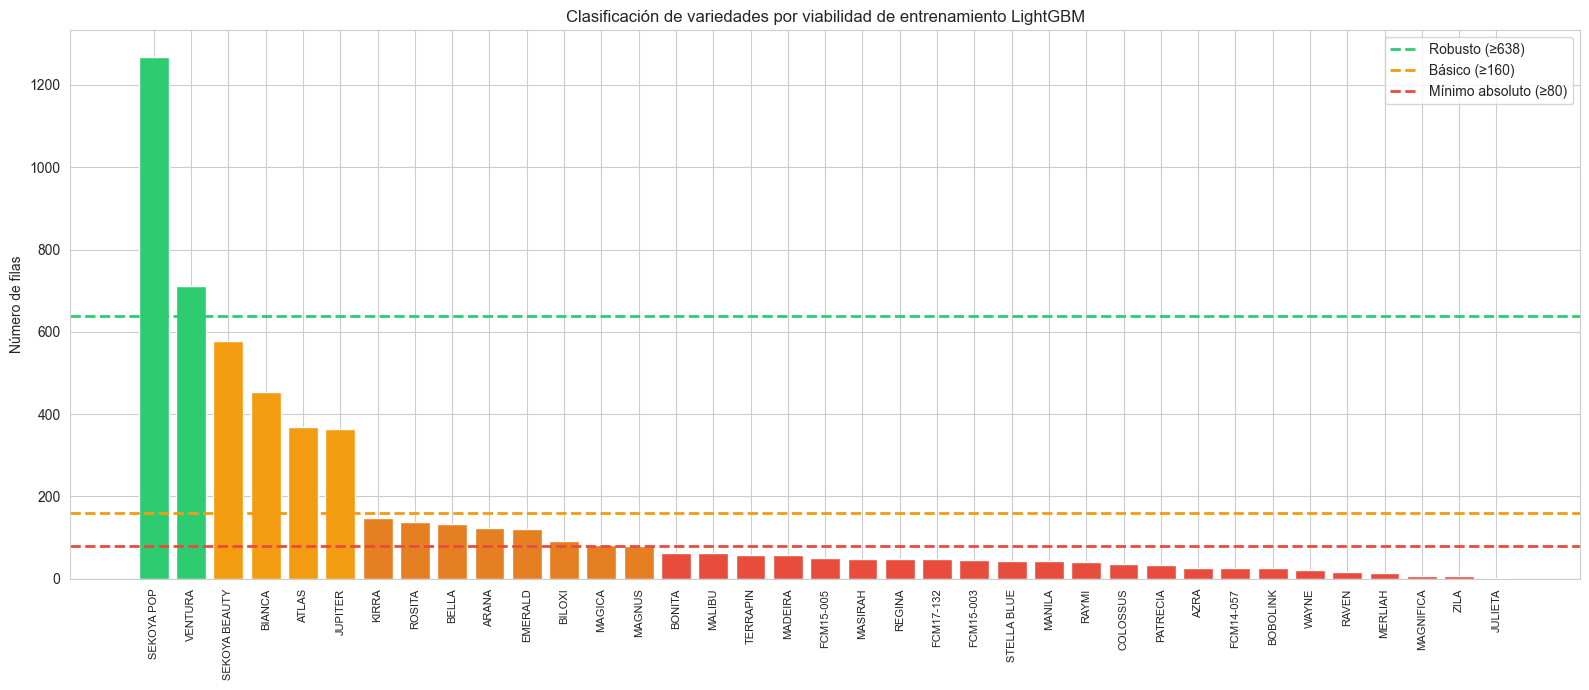

✓ Robusto: 2
~ Básico: 4
⚠ Mínimo: 8
✗ Insuficiente: 23


In [7]:
plot_viability_chart(summary_df, config.thresholds)

---
## 2. Distancia de Wasserstein y asignación a anclas

Para cada variedad no-ancla medimos qué tan parecida es su **distribución** a cada
una de las 11 anclas, y la asignamos a la más cercana.

### Cómo funciona

1. **Normalización:** `StandardScaler` sobre las 5 features (media 0, varianza 1) para que ninguna feature domine por su escala.
2. **Distancia por feature:** para cada feature calculamos la distancia Wasserstein-1 entre la variedad y el ancla.
3. **Distancia agregada:** promedio de las 5 distancias por feature.
4. **Asignación:** la variedad va al ancla con **menor distancia promedio**.

### ¿Por qué Wasserstein y no otra métrica?

| Métrica | ¿Qué mide? | Problema para este caso |
|---------|-----------|-------------------------|
| **Euclidiana** | Distancia entre medias | Ignora forma y varianza — 2 variedades con misma media pero muy distintas en varianza se verían iguales |
| **KL divergence** | Diferencia entre densidades | Requiere estimar densidades (KDE), asume continuidad, explota cuando hay poco solapamiento |
| **Wasserstein** ✓ | "Costo" de transformar una distribución en otra | Captura forma completa; robusta con pocos datos; interpretable en las unidades originales |

### Qué salida produce

`assignment_df` — una fila por variedad no-ancla con: `variedad`, `ancla_asignada`, `distancia_wass`, y las distancias top-2 para entender si la asignación fue "obvia" o "ajustada".


In [ ]:
scaled_data = normalize_features(all_data, config.features)
scaled_data = filter_outliers(
    scaled_data,
    config.features,
    contamination=config.outlier_contamination,
    random_state=RANDOM_STATE,
)
print(
    f"Outliers filtrados "
    f"(contamination={config.outlier_contamination:.0%} por variedad)"
)
assignment_df = assign_to_anchors(
    non_anchor_names, anchor_names, all_data, scaled_data, config.features
)

# Mostrar agrupado por ancla
print("=" * 80)
print("ASIGNACIÓN DE VARIEDADES A ANCLAS (Wasserstein)")
print("=" * 80)

for anchor in sorted(anchor_names):
    assigned = assignment_df[assignment_df["ancla_asignada"] == anchor]
    total_group = len(all_data[anchor]) + assigned["n_filas"].sum()
    print(f"\n{'─' * 70}")
    print(f"  ⚓ {anchor} ({len(all_data[anchor])} propias, {total_group} total)")
    print(f"{'─' * 70}")
    if len(assigned) > 0:
        for _, row in assigned.sort_values("distancia_wass").iterrows():
            print(
                f"    ← {row['variedad']:20s} ({row['n_filas']:4d} filas) "
                f"dist={row['distancia_wass']:.3f}  "
                f"(2da: {row['segunda_opcion']} dist={row['dist_segunda']:.3f})"
            )
    else:
        print("    (sin variedades asignadas)")

print(f"\nTotal asignaciones: {len(assignment_df)}")
assignment_df

---
## 3. Validación — Mann-Whitney U

Para cada asignación variedad → ancla, aplicamos **Mann-Whitney U** feature por
feature. Contamos cuántas features tienen `p > 0.05` (las distribuciones no son
significativamente diferentes → se pueden tratar como similares).

### Regla de aceptación

| % features similares | Lectura |
|---|---|
| **≥ 80%** | Asignación excelente — la variedad se comporta como el ancla |
| **60–79%** | Asignación aceptable — hereda el modelo del ancla con confianza |
| **< 60%** | Asignación débil — el ancla más cercana existe pero la distribución difiere en demasiadas features |

### ¿Qué hacemos con las asignaciones débiles?

**Se mantiene la asignación** al ancla más cercana por Wasserstein. Razón: aunque los tests univariados (Mann-Whitney por feature) salgan significativos, Wasserstein captura similitud en la forma completa de la distribución. La tabla de decisión final (sección 6) las marca explícitamente como "revisar" para que puedas:

- Aceptar la asignación si el modelo del ancla funciona en producción
- O decidir entrenar esa variedad como su propio ancla si hay datos suficientes

> **Edge case conocido:** variedades con `n < 3` filas (ej. `JULIETA`) devuelven 0%
> porque Mann-Whitney requiere ≥3 observaciones. La tabla de decisión las marca
> con `"insuficiente"` en vez de `"revisar"` para no confundir.


In [9]:
validation_df = validate_mann_whitney(
    assignment_df, all_data, config.features, config.alpha
)

print("=" * 80)
print("VALIDACIÓN: Mann-Whitney U (p > 0.05 = similares)")
print("=" * 80)
print(f"\n  {'variedad':20s}   {'ancla':20s}  {'similares':>10s} {'%':>6s}")
print("  " + "─" * 68)
for _, r in validation_df.iterrows():
    print(
        f"  {r['variedad']:20s} → {r['ancla']:20s} "
        f"{r['features_similares']:>10s} {r['pct_similar']:5.0f}%  {r['status']}"
    )

good = (validation_df["pct_similar"] >= config.min_similar_pct).sum()
print(
    f"\n✓ {good}/{len(validation_df)} asignaciones con ≥{config.min_similar_pct:.0f}% features similares"
)

low = validation_df[validation_df["pct_similar"] < config.min_similar_pct]
if len(low) > 0:
    print(
        f"\n⚠ Asignaciones con <{config.min_similar_pct:.0f}% similitud ({len(low)}):"
    )
    for _, r in low.iterrows():
        print(f"    {r['variedad']} → {r['ancla']} ({r['pct_similar']:.0f}%)")
    print("    (se asignan igualmente al ancla más cercana por Wasserstein)")

VALIDACIÓN: Mann-Whitney U (p > 0.05 = similares)

  variedad               ancla                  similares      %
  ────────────────────────────────────────────────────────────────────
  JULIETA              → ARANA                       0/0     0%  ⚠
  BILOXI               → JUPITER                     0/5     0%  ⚠
  REGINA               → ROSITA                      0/5     0%  ⚠
  MERLIAH              → ARANA                       1/5    20%  ⚠
  ZILA                 → ARANA                       1/5    20%  ⚠
  FCM14-057            → ARANA                       1/5    20%  ⚠
  FCM17-132            → ARANA                       1/5    20%  ⚠
  FCM15-005            → ARANA                       1/5    20%  ⚠
  FCM15-003            → ARANA                       1/5    20%  ⚠
  MAGNUS               → ROSITA                      1/5    20%  ⚠
  RAVEN                → JUPITER                     2/5    40%  ⚠
  MAGNIFICA            → JUPITER                     2/5    40%  ⚠
  WAYNE  

---
## 4. Resultado final + export CSV

Combinamos las anclas (con sus propios datos) y las no-anclas (con su ancla asignada)
en un único `final_result`. Exportamos dos CSVs para consumo inmediato:

| Archivo | Uso |
|---------|-----|
| `variety_anchor_assignment.csv` | Tabla completa con zona de viabilidad, distancia Wasserstein y notas |
| `variety_training_mapping.csv` | Mapping simplificado `variedad → entrena_con` (útil para scripts) |

> Los dos CSVs son **intermedios**. El artefacto "fuente de verdad" que consumirá
> `modelo_nuevo_ml.ipynb` es el **YAML** que se genera en la sección 6, una vez
> que tenemos también los resultados de los 4 tests de validación global.


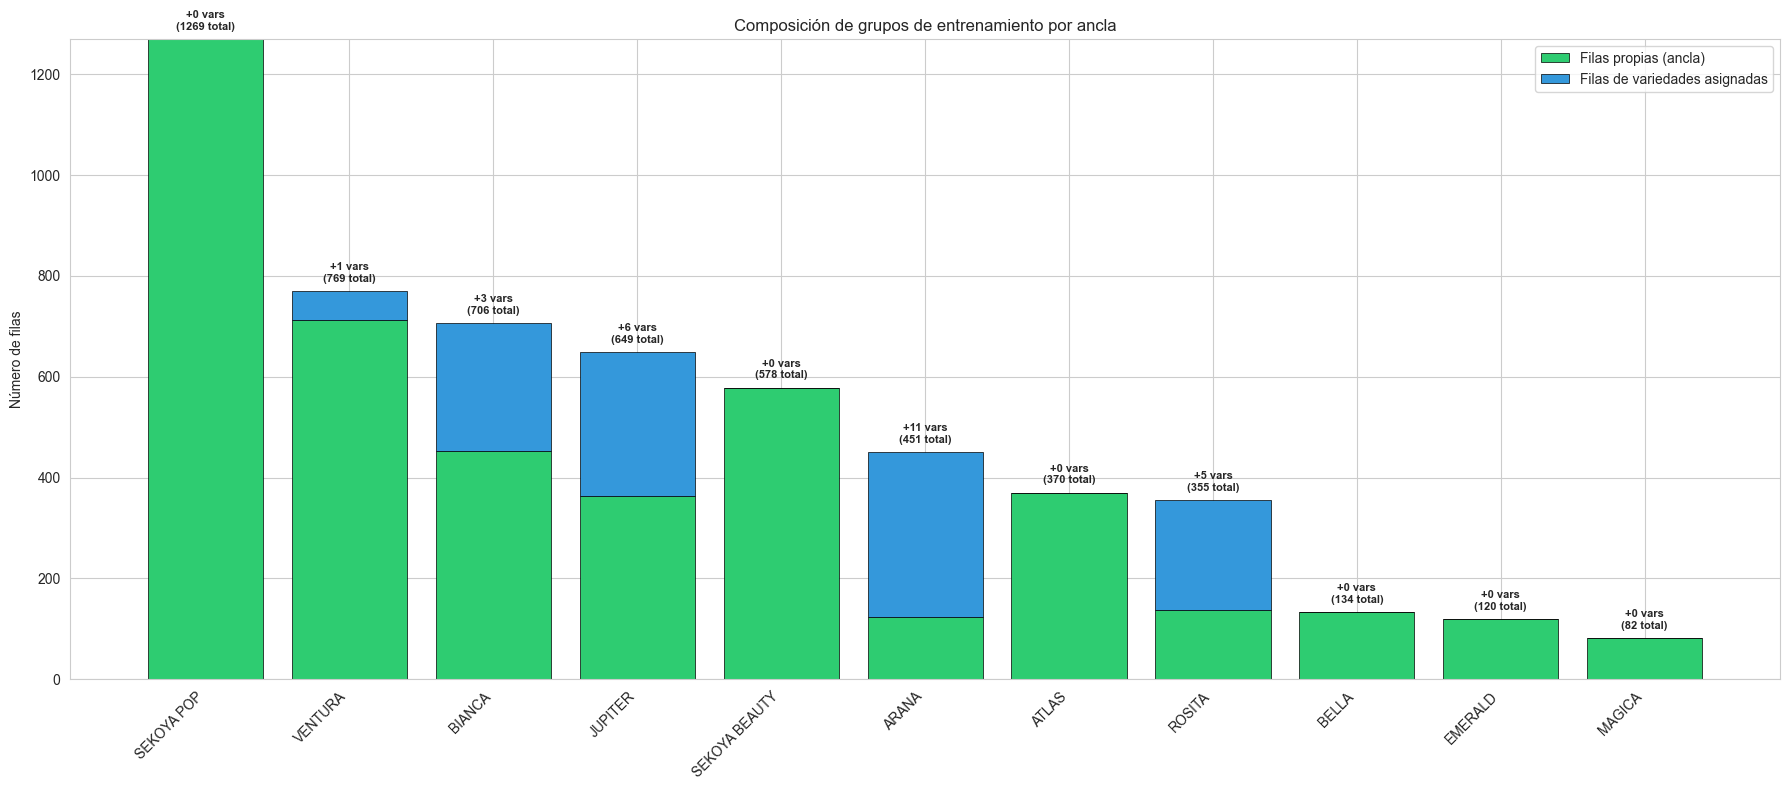

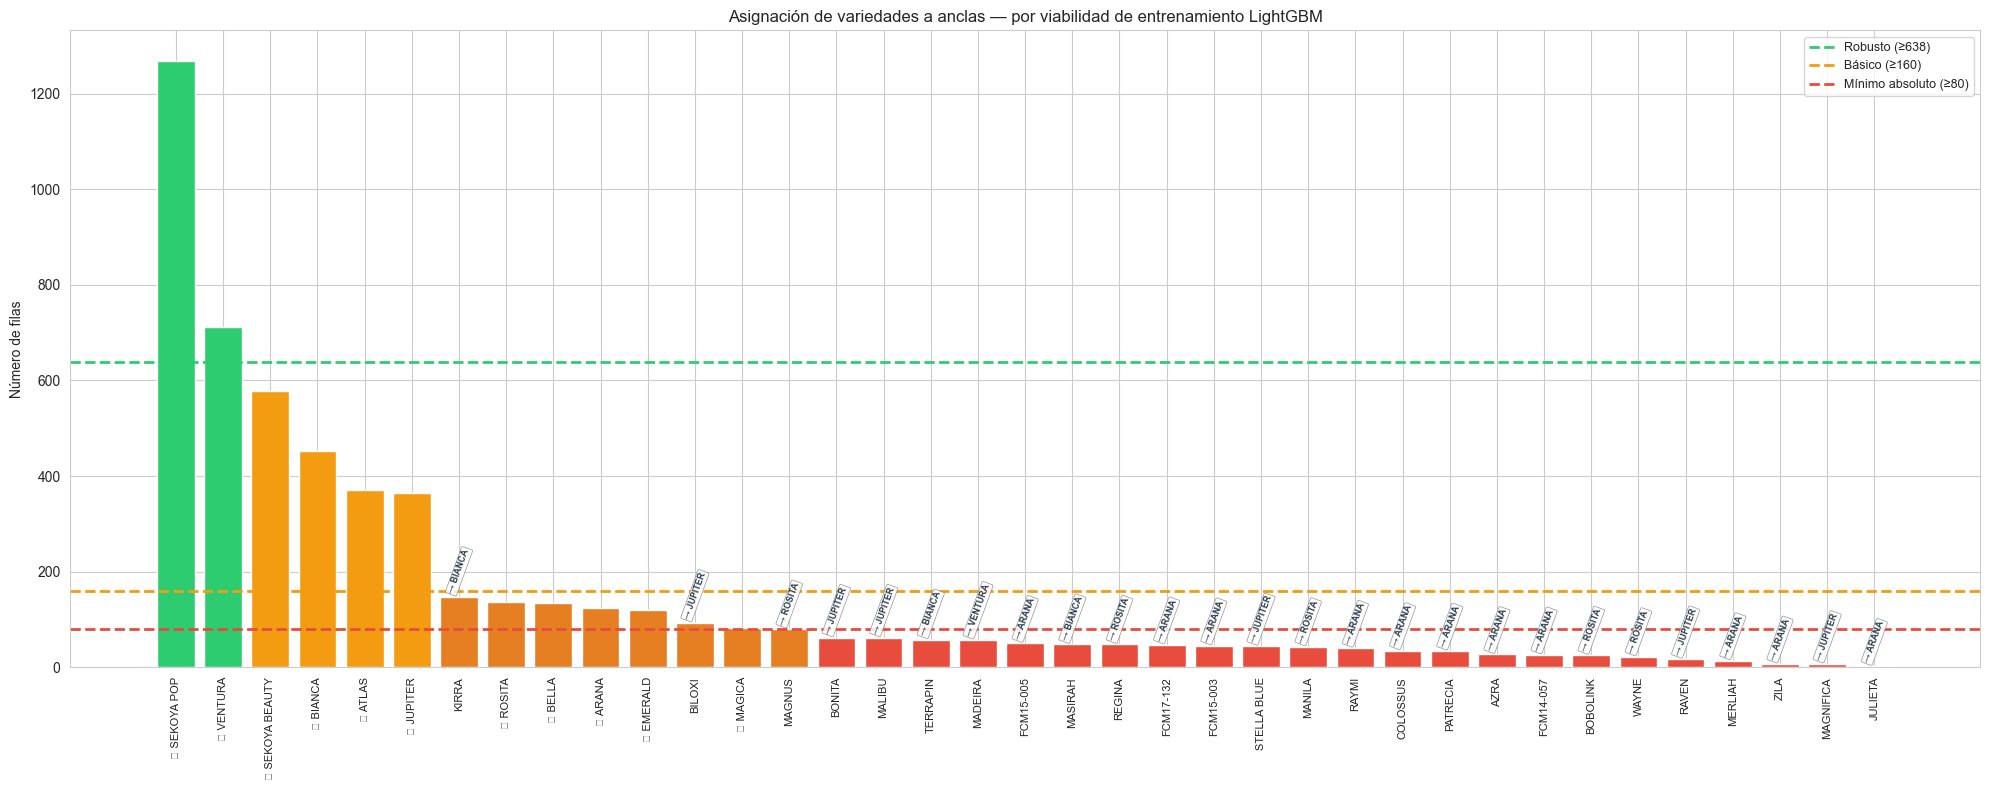

Total filas para entrenamiento: 5483
Anclas: 11 | Asignadas: 26


,variedad,n_filas,zona,entrena_con,ancla_asignada,distancia_wass,nota
17,FCM15-005,50,⬛ Agrupar,ARANA,ARANA,0.7606,"Vecino más cercano: ARANA (dist=0.761, similit..."
16,FCM17-132,47,⬛ Agrupar,ARANA,ARANA,0.4654,"Vecino más cercano: ARANA (dist=0.465, similit..."
21,FCM15-003,45,⬛ Agrupar,ARANA,ARANA,0.6219,"Vecino más cercano: ARANA (dist=0.622, similit..."
12,RAYMI,40,⬛ Agrupar,ARANA,ARANA,0.3356,"Vecino más cercano: ARANA (dist=0.336, similit..."
20,COLOSSUS,35,⬛ Agrupar,ARANA,ARANA,0.2350,"Vecino más cercano: ARANA (dist=0.235, similit..."
13,PATRECIA,34,⬛ Agrupar,ARANA,ARANA,0.4709,"Vecino más cercano: ARANA (dist=0.471, similit..."
11,AZRA,27,⬛ Agrupar,ARANA,ARANA,0.3075,"Vecino más cercano: ARANA (dist=0.307, similit..."
19,FCM14-057,26,⬛ Agrupar,ARANA,ARANA,0.7168,"Vecino más cercano: ARANA (dist=0.717, similit..."
14,MERLIAH,14,⬛ Agrupar,ARANA,ARANA,0.4340,"Vecino más cercano: ARANA (dist=0.434, similit..."
18,ZILA,7,⬛ Agrupar,ARANA,ARANA,0.7392,"Vecino más cercano: ARANA (dist=0.739, similit..."


In [10]:
final_result = build_final_result(
    anchor_names, assignment_df, validation_df, all_data, config.thresholds
)
group_summary = compute_group_summary(anchor_names, assignment_df, all_data)

# Gráfico 1: Composición por grupo
plot_group_composition(group_summary)

# Gráfico 2: Asignación estilo viabilidad
plot_assignment_chart(final_result, config.thresholds)

# Resumen
print(f"Total filas para entrenamiento: {group_summary['total'].sum()}")
print(f"Anclas: {len(anchor_names)} | Asignadas: {len(assignment_df)}")
final_result

In [11]:
export_df, mapping_df = export_results(final_result, config.output_dir)
export_df

✓ Exportado a ../data/variety_anchor_assignment.csv
✓ Exportado a ../data/variety_training_mapping.csv


,variedad,n_filas,zona,entrena_con,distancia_wass,nota
17,FCM15-005,50,⬛ Agrupar,ARANA,0.7606,"Vecino más cercano: ARANA (dist=0.761, similit..."
16,FCM17-132,47,⬛ Agrupar,ARANA,0.4654,"Vecino más cercano: ARANA (dist=0.465, similit..."
21,FCM15-003,45,⬛ Agrupar,ARANA,0.6219,"Vecino más cercano: ARANA (dist=0.622, similit..."
12,RAYMI,40,⬛ Agrupar,ARANA,0.3356,"Vecino más cercano: ARANA (dist=0.336, similit..."
20,COLOSSUS,35,⬛ Agrupar,ARANA,0.2350,"Vecino más cercano: ARANA (dist=0.235, similit..."
13,PATRECIA,34,⬛ Agrupar,ARANA,0.4709,"Vecino más cercano: ARANA (dist=0.471, similit..."
11,AZRA,27,⬛ Agrupar,ARANA,0.3075,"Vecino más cercano: ARANA (dist=0.307, similit..."
19,FCM14-057,26,⬛ Agrupar,ARANA,0.7168,"Vecino más cercano: ARANA (dist=0.717, similit..."
14,MERLIAH,14,⬛ Agrupar,ARANA,0.4340,"Vecino más cercano: ARANA (dist=0.434, similit..."
18,ZILA,7,⬛ Agrupar,ARANA,0.7392,"Vecino más cercano: ARANA (dist=0.739, similit..."


## 5. Sustento estadístico de la agrupación

**¿Por qué validar?** Asignamos cada variedad al ancla más cercana por Wasserstein, pero necesitamos demostrar que esta agrupación **no es arbitraria** y que tiene sentido estadístico.

Usamos **4 tests independientes**, cada uno responde una pregunta distinta:

| # | Test | Pregunta que responde | ¿Qué es "bueno"? |
|---|------|-----------------------|-------------------|
| 1 | **Silhouette Score** | ¿Cada variedad está más cerca de su ancla que de las otras anclas? | Score > 0.25 (rango -1 a 1) |
| 2 | **Ratio intra/inter** | ¿La distancia dentro del grupo es menor que la distancia entre grupos? | Ratio < 1.0 (mientras más bajo, mejor) |
| 3 | **Kruskal-Wallis** | ¿Los 11 grupos son realmente diferentes entre sí en cada feature? | p < 0.05 en ≥3 de 5 features |
| 4 | **PERMANOVA** | ¿La agrupación explica la varianza de los datos mejor que el azar? | p < 0.05 y R² alto |

**Interpretación:** Si ≥3 de 4 tests pasan → la agrupación tiene **sustento estadístico sólido** para usarse en entrenamiento.

In [12]:
validation_tests = run_all_validations(
    final_result,
    assignment_df,
    anchor_names,
    all_data,
    scaled_data,
    config.features,
    config.n_permutations,
)


✗ Silhouette Score
   Score global: 0.0544 — Bajo
   ⚓ ARANA               : -0.081
   ⚓ BIANCA              : +0.550
   ⚓ JUPITER             : -0.050
   ⚓ ROSITA              : -0.043
   ⚓ VENTURA             : +0.532

✓ Ratio intra/inter
   Intra-grupo: 0.3850  |  Inter-grupo: 0.7094
   Ratio: 0.5427 — Bueno

✓ Kruskal-Wallis
   KGHECT                H=    772.56  p=1.63e-159  ✓ Sig.
   INDUSTRIAL            H=    626.23  p=4.20e-128  ✓ Sig.
   DPC                   H=   2430.31  p=0.00e+00  ✓ Sig.
   PesoBayaFIMPRO        H=   2979.43  p=0.00e+00  ✓ Sig.
   KGHORA                H=    750.72  p=8.04e-155  ✓ Sig.
   → 5/5 features significativas

✓ PERMANOVA
   F=5.8726  p=0.0010  R²=0.6931 (69.3%)

RESUMEN: 3/4 tests apoyan la agrupación
   ✗ Silhouette Score
   ✓ Ratio intra/inter
   ✓ Kruskal-Wallis
   ✓ PERMANOVA

   → ✅ SUSTENTO ESTADÍSTICO SÓLIDO


---
## 5.05 Validación de k óptimo (barrido silhouette)

El silhouette global de la sección 5.1 puede salir **negativo** si el número
de anclas (k) no coincide con la estructura natural de los datos. Aquí
hacemos un barrido de k = `k_sweep_min` a `k_sweep_max` usando KMeans
sobre las observaciones escaladas (ya filtradas de outliers), y comparamos
el silhouette que obtiene la agrupación **inducida por las anclas actuales**
contra el mejor k que encontraría KMeans libre.

- Si el codo está en el **mismo k** que `len(anchor_varieties)`: el número
  de anclas es correcto.
- Si el mejor k es **menor**: hay anclas redundantes, considerar fusionar
  algunas.
- Si el mejor k es **mayor**: las anclas actuales no capturan toda la
  heterogeneidad; considerar agregar una ancla nueva.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5.05  Barrido de k óptimo por silhouette
# ══════════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans

# Apilar todas las observaciones escaladas (post-outlier filter)
obs_parts_k = [df[config.features].values for df in scaled_data.values()]
X_all_k = np.vstack(obs_parts_k)

k_current = len(anchor_names)
k_range = list(range(config.k_sweep_min, config.k_sweep_max + 1))
sil_scores_k = []

print("=" * 70)
print(f"Barrido k = {k_range[0]}..{k_range[-1]}  (k actual = {k_current})")
print("=" * 70)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_all_k)
    sil_k = silhouette_score(X_all_k, labels_k, metric="euclidean")
    sil_scores_k.append(sil_k)
    mark = " ← k actual" if k == k_current else ""
    print(f"  k={k:>2}  silhouette={sil_k:+.4f}{mark}")

best_k = k_range[int(np.argmax(sil_scores_k))]
best_sil = max(sil_scores_k)
sil_at_current = sil_scores_k[k_range.index(k_current)] if k_current in k_range else float("nan")

print()
print(f"  Mejor k (KMeans libre):   k={best_k}  silhouette={best_sil:+.4f}")
print(f"  Silhouette con k actual:  k={k_current}  silhouette={sil_at_current:+.4f}")
delta_k = best_k - k_current
if abs(delta_k) <= 1:
    verdict_k = "✓ k actual coincide con el óptimo (±1)"
elif delta_k < 0:
    verdict_k = f"⚠ Posible redundancia: óptimo k={best_k} < actual k={k_current}"
else:
    verdict_k = f"⚠ Heterogeneidad no cubierta: óptimo k={best_k} > actual k={k_current}"
print(f"  Veredicto: {verdict_k}")

# Gráfico del codo
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, sil_scores_k, marker="o", linewidth=2)
ax.axvline(k_current, color="#f59e0b", linestyle="--", label=f"k actual = {k_current}")
ax.axvline(best_k, color="#10b981", linestyle="--", label=f"k óptimo = {best_k}")
ax.set_xlabel("k (número de clusters)")
ax.set_ylabel("Silhouette global")
ax.set_title("Barrido de k óptimo — curva codo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5.1 Análisis estadístico reforzado

Los 4 tests de la sección 5 dan una **foto global** (¿hay señal?), pero tienen
tres limitaciones conocidas con esta data:

| Limitación | Impacto | Corrección aplicada |
|---|---|---|
| Silhouette + PERMANOVA corren sobre **37 centroides** en vez de las ~4.300 observaciones | Baja potencia estadística | **Silhouette global** sobre todas las obs |
| Mann-Whitney por feature **sin corrección** de comparaciones múltiples | α real ≈ 23% (no 5%) con 5 tests → % similares inflado | **Holm-Bonferroni** step-down |
| No sabemos qué tan **frágil** es cada asignación individual | "Revisar" es una categoría opaca | **Bootstrap 100×** por variedad |

### Qué aporta cada técnica

#### (a) Bootstrap stability — ¿es robusta la asignación?

Para cada variedad no-ancla: resampleamos con reemplazo sus filas 100 veces; en cada iteración recomputamos su ancla nearest por Wasserstein. **Stability %** = proporción de iteraciones que cayeron en el ancla canónica.

- **≥ 90%** → asignación muy robusta (la data es consistente con el ancla)
- **60–89%** → asignación razonable pero con alternativa competitiva
- **< 60%** → asignación frágil; considerar entrenarla como ancla propia o revisar datos

Este es **el número más accionable para gerencia**: pasa "revisar" de etiqueta a probabilidad.

#### (b) Silhouette sobre todas las observaciones

El Silhouette de la sección 5 usa los 37 centroides (1 por variedad). Con solo 37 puntos en 5D y 11 grupos, el test tiene poca potencia. Aquí lo corremos sobre las ~4.300 observaciones individuales etiquetadas por su ancla asignada — más realista y con mayor poder estadístico.

#### (c) Mann-Whitney con corrección Holm-Bonferroni

Correr MW 5 veces (una por feature) con α=0.05 infla el error tipo I: probabilidad de al menos un falso positivo ≈ **1 - 0.95⁵ = 23%**. Holm-Bonferroni es un step-down que ajusta cada umbral por el rank del p-value, más potente que Bonferroni simple y sigue controlando el FWER al 5%.

La métrica `pct_similar_holm` es una versión más honesta de `pct_similar`: típicamente algunas asignaciones "aceptables" caen al aplicar la corrección.

### Cómo leer los resultados

| Si ves… | Significa… |
|---|---|
| Variedad con `stability < 60%` y `pct_similar_holm < 40%` | Asignación realmente frágil — evaluar entrenar como ancla propia |
| Variedad con `stability ≥ 90%` y `pct_similar_holm < 60%` | Ancla nearest robusta pero feature-level difiere — aceptable para modelo de regresión |
| `sil_all` mucho mayor que `sil_centroides` | La estructura del grupo es real pero se diluye al agregar por centroide |
| `n_raw - n_holm > 3` | La corrección importa — el reporte sin corrección era demasiado optimista |


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5.1  Análisis estadístico reforzado
# ------------------------------------------------------------------
# Complementa los 4 tests de la sección 5 con:
#   (a) Bootstrap stability — ¿qué tan frágil es cada asignación?
#   (b) Silhouette sobre TODAS las observaciones (no solo centroides)
#   (c) Mann-Whitney U con corrección Holm-Bonferroni
#
# Produce:
#   - stability_df   (variedad, stability_pct, top_alternative)
#   - sil_all        (silhouette score sobre ~4.300 observaciones)
#   - mw_holm_df     (pct_similar_holm tras corrección de tests múltiples)
#
# Estos 3 artefactos los consume la sección 6 (tabla de decisión y YAML).
# ══════════════════════════════════════════════════════════════════
import numpy as np
from scipy.stats import mannwhitneyu, wasserstein_distance
from sklearn.metrics import silhouette_score

try:
    from statsmodels.stats.multitest import multipletests

    _HAS_STATSMODELS = True
except ImportError:
    _HAS_STATSMODELS = False


def _holm_manual(pvals, alpha):
    """Fallback Holm-Bonferroni si no hay statsmodels."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    rejected = np.zeros(n, dtype=bool)
    for i, idx in enumerate(order):
        thr = alpha / (n - i)
        if pvals[idx] <= thr:
            rejected[idx] = True
        else:
            break  # step-down: una vez que no rechaza, paramos
    return rejected


def _apply_holm(pvals, alpha):
    if _HAS_STATSMODELS:
        rejected, _, _, _ = multipletests(pvals, alpha=alpha, method="holm")
        return rejected
    return _holm_manual(pvals, alpha)


# ── 5.1.1  Bootstrap stability ──────────────────────────────────────
BOOTSTRAP_ITERATIONS = 100
BOOTSTRAP_SEED = 42
rng = np.random.default_rng(BOOTSTRAP_SEED)

print("=" * 70)
print(f"Bootstrap stability ({BOOTSTRAP_ITERATIONS} iter por variedad no-ancla)")
print("=" * 70)


def _mean_wass_arr(sample_arr, anchor_arr):
    """Wasserstein promedio por feature entre dos arrays (n×f) y (m×f)."""
    return np.mean(
        [
            wasserstein_distance(sample_arr[:, i], anchor_arr[:, i])
            for i in range(sample_arr.shape[1])
        ]
    )


# Ancla canónica de cada variedad (incluye las anclas mismas)
anchor_of_map = {r["variedad"]: r["entrena_con"] for _, r in final_result.iterrows()}

# Pre-cachear arrays escalados de anclas (no varían entre bootstraps)
anchors_arr = {a: scaled_data[a][config.features].values for a in anchor_names}

non_anchor_list = [v for v in all_data.keys() if v not in anchor_names]
stability_rows = []

for variety in non_anchor_list:
    if variety not in scaled_data:
        continue
    X_var = scaled_data[variety][config.features].values
    n = len(X_var)
    if n < 2:
        stability_rows.append(
            {
                "variedad": variety,
                "ancla_canonica": anchor_of_map[variety],
                "stability_pct": 0.0,
                "top_alternative": "—",
                "top_alt_pct": 0.0,
                "note": f"n={n} (insuficiente para bootstrap)",
            }
        )
        continue

    counts = {a: 0 for a in anchor_names}
    for _ in range(BOOTSTRAP_ITERATIONS):
        idx = rng.integers(0, n, size=n)
        sample = X_var[idx]
        best_a, best_d = None, float("inf")
        for a, a_arr in anchors_arr.items():
            d = _mean_wass_arr(sample, a_arr)
            if d < best_d:
                best_d, best_a = d, a
        counts[best_a] += 1

    canon = anchor_of_map[variety]
    stability = counts[canon] / BOOTSTRAP_ITERATIONS * 100
    alternatives = sorted(
        [(a, c) for a, c in counts.items() if a != canon], key=lambda x: -x[1]
    )
    top_alt = alternatives[0] if alternatives else ("—", 0)
    stability_rows.append(
        {
            "variedad": variety,
            "ancla_canonica": canon,
            "stability_pct": stability,
            "top_alternative": top_alt[0],
            "top_alt_pct": top_alt[1] / BOOTSTRAP_ITERATIONS * 100,
            "note": "",
        }
    )

stability_df = pd.DataFrame(stability_rows).sort_values("stability_pct")

# ── Holm sobre p-valores binomiales del bootstrap ──────────────────
# H0: la variedad se asigna al ancla canónica por azar (p = 1/k_anchors).
# Bajo H0, counts[canon] ~ Binomial(BOOTSTRAP_ITERATIONS, 1/k).
# Un stability_pct alto SOLO vale si es significativamente mayor al azar.
from scipy.stats import binom as _binom
k_anc = len(anchor_names)
p_null = 1.0 / k_anc
pvals_boot = []
for _, r in stability_df.iterrows():
    c = int(round(r["stability_pct"] / 100 * config.bootstrap_iterations))
    # P(X >= c) bajo Binomial(n, p_null)
    p = float(1 - _binom.cdf(c - 1, config.bootstrap_iterations, p_null))
    pvals_boot.append(p)
rejected_boot = _apply_holm(np.array(pvals_boot), config.alpha)
stability_df = stability_df.assign(
    p_null_holm=pvals_boot,
    boot_significant=rejected_boot,
)
n_sig_boot = int(rejected_boot.sum())

n_robust = (stability_df["stability_pct"] >= 90).sum()
n_fragile = (stability_df["stability_pct"] < 60).sum()
print(f"\n  Robustas    (stability ≥ 90%): {n_robust:>2}/{len(stability_df)}")
print(
    f"  Intermedias (60-89%)          : "
    f"{((stability_df['stability_pct'] >= 60) & (stability_df['stability_pct'] < 90)).sum():>2}/{len(stability_df)}"
)
print(f"  Frágiles    (< 60%)           : {n_fragile:>2}/{len(stability_df)}")
print(
    f"  Holm-sig vs azar (1/{k_anc}):  "
    f"{n_sig_boot:>2}/{len(stability_df)} "
    f"(rechaza H0 tras corrección múltiple)"
)

weak = stability_df[stability_df["stability_pct"] < 80]
if len(weak) > 0:
    print(f"\n  Asignaciones con stability < 80%:")
    print(
        f"  {'variedad':20s}    {'canónica':12s}  {'stab':>7s}  "
        f"{'top alt':12s}  {'%':>6s}"
    )
    print("  " + "─" * 68)
    for _, r in weak.iterrows():
        print(
            f"  {r['variedad']:20s} →  {r['ancla_canonica']:12s} "
            f"{r['stability_pct']:6.1f}%  "
            f"{r['top_alternative']:12s} {r['top_alt_pct']:5.1f}%"
        )


# ── 5.1.2  Silhouette sobre TODAS las observaciones ─────────────────
print()
print("=" * 70)
print(f"Silhouette sobre todas las observaciones (no solo centroides)")
print("=" * 70)

obs_parts = []
labels_parts = []
for variety, df_scaled in scaled_data.items():
    obs_parts.append(df_scaled[config.features].values)
    labels_parts.extend([anchor_of_map[variety]] * len(df_scaled))

X_all = np.vstack(obs_parts)
y_all = np.array(labels_parts)

sil_all = float(silhouette_score(X_all, y_all, metric="euclidean"))
sil_centroides = float(validation_tests[0].get("score", 0.0))

print(f"\n  Observaciones usadas: {len(X_all):,}")
print(f"  Silhouette global:    {sil_all:+.4f}")
print(f"  (vs. {sil_centroides:+.4f} sobre 37 centroides)")
qual_all = "Excelente" if sil_all > 0.5 else "Aceptable" if sil_all > 0.25 else "Bajo"
print(f"  Calidad: {qual_all}")


# ── 5.1.3  Mann-Whitney U con corrección Holm-Bonferroni ────────────
print()
print("=" * 70)
print(f"Mann-Whitney U con corrección Holm-Bonferroni (α={config.alpha})")
print("=" * 70)


def _pct_similar_holm(v_data_by_feat, a_data_by_feat, features, alpha):
    """Calcula % de features considerados similares tras Holm-Bonferroni."""
    pvals = []
    for feat in features:
        v_d = v_data_by_feat.get(feat)
        a_d = a_data_by_feat.get(feat)
        if v_d is None or a_d is None or len(v_d) < 3 or len(a_d) < 3:
            pvals.append(np.nan)
            continue
        try:
            _, p = mannwhitneyu(v_d, a_d, alternative="two-sided")
            pvals.append(float(p))
        except Exception:
            pvals.append(np.nan)
    valid_p = np.array([p for p in pvals if not np.isnan(p)])
    if len(valid_p) == 0:
        return 0.0, 0, 0
    rej = _apply_holm(valid_p, alpha)
    n_sim = int((~rej).sum())
    return n_sim / len(valid_p) * 100, n_sim, len(valid_p)


# Calibrar umbral MW-Holm con el null de parejas *no-asignadas*:
# para cada variedad no-ancla, calculamos pct_similar_holm contra TODAS las
# anclas NO asignadas → distribución de 'qué tan similar se ve una ancla
# mismatched'. El umbral = percentile configurado sobre ese null.
_feat_cache = {
    name: {f: all_data[name][f].dropna().values for f in config.features}
    for name in all_data.keys()
}
null_pcts = []
for _, r in validation_df.iterrows():
    v = r["variedad"]
    assigned = r["ancla"]
    for a in anchor_names:
        if a == assigned:
            continue
        pct, _, _ = _pct_similar_holm(
            _feat_cache[v], _feat_cache[a], config.features, config.alpha
        )
        null_pcts.append(pct)

if null_pcts:
    mw_holm_threshold_calibrated = float(
        np.percentile(null_pcts, config.mw_holm_null_percentile)
    )
else:
    mw_holm_threshold_calibrated = float(config.min_similar_pct)

print(
    f"  Umbral MW-Holm calibrado: "
    f"p{config.mw_holm_null_percentile:.0f} del null = "
    f"{mw_holm_threshold_calibrated:.1f}%  "
    f"(fijo anterior: {config.min_similar_pct:.0f}%)"
)
print(
    f"  Null generado sobre {len(null_pcts)} pares variedad-ancla "
    f"no asignados"
)

mw_holm_rows = []
for _, r in validation_df.iterrows():
    variety, anchor = r["variedad"], r["ancla"]
    pvals = []
    for feat in config.features:
        v_data = all_data[variety][feat].dropna().values
        a_data = all_data[anchor][feat].dropna().values
        if len(v_data) < 3 or len(a_data) < 3:
            pvals.append(np.nan)
            continue
        try:
            _, p = mannwhitneyu(v_data, a_data, alternative="two-sided")
            pvals.append(float(p))
        except Exception:
            pvals.append(np.nan)

    valid_mask = ~np.isnan(pvals)
    valid_p = np.array(pvals)[valid_mask]

    if len(valid_p) == 0:
        n_sim_holm, pct_holm = 0, 0.0
    else:
        rejected = _apply_holm(valid_p, config.alpha)
        n_sim_holm = int((~rejected).sum())
        pct_holm = n_sim_holm / len(valid_p) * 100

    mw_holm_rows.append(
        {
            "variedad": variety,
            "ancla": anchor,
            "n_similar_holm": n_sim_holm,
            "n_total_valid": int(valid_mask.sum()),
            "pct_similar_holm": pct_holm,
        }
    )

mw_holm_df = pd.DataFrame(mw_holm_rows)

n_raw = int((validation_df["pct_similar"] >= config.min_similar_pct).sum())
n_holm = int((mw_holm_df["pct_similar_holm"] >= config.min_similar_pct).sum())
n_holm_cal = int(
    (mw_holm_df["pct_similar_holm"] >= mw_holm_threshold_calibrated).sum()
)
delta = n_raw - n_holm

print(
    f"\n  Asignaciones ≥{config.min_similar_pct:.0f}% (raw MW):         "
    f"{n_raw:>2}/{len(validation_df)}"
)
print(
    f"  Asignaciones ≥{config.min_similar_pct:.0f}% (Holm, fijo):      "
    f"{n_holm:>2}/{len(mw_holm_df)}"
)
print(
    f"  Asignaciones ≥{mw_holm_threshold_calibrated:.1f}% (Holm, calibrado): "
    f"{n_holm_cal:>2}/{len(mw_holm_df)}"
)
if delta > 0:
    print(f"  → {delta} asignaciones bajaron al corregir por comparaciones múltiples")
elif delta < 0:
    print(f"  → {abs(delta)} asignaciones subieron (raro — revisar)")
else:
    print(f"  → Sin cambios tras la corrección")


# ── 5.1.4  Resumen ejecutivo del análisis reforzado ─────────────────
print()
print("=" * 70)
print("RESUMEN — Análisis estadístico reforzado")
print("=" * 70)
print(f"  Bootstrap:  {n_robust}/{len(stability_df)} asignaciones robustas (≥90%)")
print(f"  Bootstrap Holm-sig (vs 1/{k_anc}): {n_sig_boot}/{len(stability_df)}")
print(f"  Silhouette: {sil_all:+.4f} sobre {len(X_all):,} obs — {qual_all}")
print(
    f"  MW Holm:    {n_holm_cal}/{len(mw_holm_df)} asignaciones "
    f"≥{mw_holm_threshold_calibrated:.1f}% (umbral calibrado)"
)
print()
print(
    "✓ stability_df (+ boot_significant), sil_all, mw_holm_df, "
    "mw_holm_threshold_calibrated disponibles para la sección 6"
)

---
## 6. Tabla de decisión ejecutiva + YAML

Consolida los resultados de **todas** las secciones anteriores (1–5 y 5.1) en un
único artefacto ejecutivo y el YAML que consumirá el notebook de entrenamiento.

### Qué produce

| Artefacto | Consumidor | Contenido |
|-----------|-----------|-----------|
| `decision_table.csv` | Analistas · Excel | Tabla plana con métricas crudas + reforzadas por variedad |
| `decision_table.html` | **Gerencia** | KPIs + tabla con semáforos + leyenda — decisión reforzada |
| `variety_anchor_mapping.yaml` | `modelo_nuevo_ml.ipynb` | Config con mapeo + metadata + validación completa |

### Dos columnas de decisión: `raw` vs `robust`

Exportamos **dos columnas**, cada una útil en contextos distintos:

#### `decision_raw` — compatible con versión anterior

Solo usa MW crudo. Mantiene retrocompatibilidad con lectores/scripts viejos.

| Categoría | Criterio |
|-----------|----------|
| 🔵 **ancla** | variedad es ancla (entrena modelo propio) |
| 🟢 **excelente** | MW ≥ 80% features similares |
| 🟢 **aceptable** | MW 60–79% |
| 🟡 **revisar** | MW < 60%, n ≥ 3 |
| ⚪ **insuficiente** | n < 3 filas |

#### `decision_robust` — **esta es la que debe leer gerencia**

Combina **bootstrap stability** (robustez) con **MW corregido por Holm** (similitud multivariante honesta).

| Categoría | Criterio | Acción |
|-----------|----------|--------|
| 🔵 **ancla** | variedad es ancla | Entrena modelo propio |
| 🟢 **robusto** | stability ≥ 90% **y** MW-Holm ≥ 60% | Hereda con alta confianza |
| 🟢 **aceptable** | stability ≥ 70% **y** MW-Holm ≥ 40% | Hereda, monitorear en prod |
| 🟡 **revisar** | stability 50–70% | Asignación ambigua — validar con negocio |
| 🔴 **fragil** | stability < 50% | Considerar entrenar como ancla propia |
| ⚪ **insuficiente** | n < 3 filas | Datos insuficientes |

### Veredicto global (4 tests de la sección 5)

| Tests pasan | Veredicto | Acción |
|---|---|---|
| **4/4** o **3/4** | `SOLIDO` | Proceder al entrenamiento |
| **2/4** | `PARCIAL` | Revisar asignaciones frágiles antes de entrenar |
| **≤1/4** | `REVISAR` | No usar — replantear la lista de anclas |

> **Para decidir rápido:** mira la columna `stability_pct` en la tabla. Si todas
> las no-anclas están ≥70%, la agrupación es accionable. Si hay varias <50%,
> revisa si conviene convertirlas en anclas propias antes de entrenar.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.  Tabla de decisión ejecutiva + YAML consumible por training
# ------------------------------------------------------------------
# Combina:
#   - final_result            (variedad → entrena_con, n_filas, zona)
#   - validation_df           (% MW similares — raw, sin corrección)
#   - mw_holm_df              (% MW similares — con Holm-Bonferroni)
#   - stability_df            (bootstrap stability % + top alternativa)
#   - validation_tests        (4 tests globales sección 5)
#   - sil_all                 (Silhouette sobre todas las observaciones)
#
# Produce 3 artefactos:
#   - decision_table.csv        (tabla plana — incluye métricas reforzadas)
#   - decision_table.html       (tablero gerencial navegable con ambas decisiones)
#   - variety_anchor_mapping.yaml  (fuente de verdad para modelo_nuevo_ml.ipynb)
# ══════════════════════════════════════════════════════════════════
from datetime import datetime
from pathlib import Path

import yaml

# ── 6.1  Construir tabla de decisión ────────────────────────────────
mw_pct_raw = dict(zip(validation_df["variedad"], validation_df["pct_similar"]))
mw_pct_holm = dict(zip(mw_holm_df["variedad"], mw_holm_df["pct_similar_holm"]))
stab_map = {
    r["variedad"]: (r["stability_pct"], r["top_alternative"], r["top_alt_pct"])
    for _, r in stability_df.iterrows()
}


def _decision_raw(row):
    """Decisión con MW crudo (compatible con versión anterior)."""
    if row["variedad"] == row["entrena_con"]:
        return ("ancla", "#0ea5e9")
    pct = mw_pct_raw.get(row["variedad"], 0.0)
    n = int(row["n_filas"])
    if n < 3:
        return ("insuficiente", "#94a3b8")
    if pct >= 80:
        return ("excelente", "#10b981")
    if pct >= 60:
        return ("aceptable", "#84cc16")
    return ("revisar", "#f59e0b")


# Umbrales calibrados para decisión robusta
_mw_thr = float(
    globals().get("mw_holm_threshold_calibrated", config.min_similar_pct)
)
_mw_thr_low = max(_mw_thr * 0.66, 1.0)  # umbral relajado para 'aceptable'
# Mapa de significancia bootstrap (Holm sobre binomial vs azar)
_boot_sig_map = {
    r["variedad"]: bool(r.get("boot_significant", False))
    for _, r in stability_df.iterrows()
}


def _decision_robust(row):
    """Decisión reforzada: bootstrap (+ Holm vs azar) + MW-Holm calibrado."""
    if row["variedad"] == row["entrena_con"]:
        return ("ancla", "#0ea5e9")
    n = int(row["n_filas"])
    if n < 3:
        return ("insuficiente", "#94a3b8")
    stab = stab_map.get(row["variedad"], (0.0, "—", 0.0))[0]
    holm = mw_pct_holm.get(row["variedad"], 0.0)
    boot_sig = _boot_sig_map.get(row["variedad"], False)
    if stab >= 90 and holm >= _mw_thr and boot_sig:
        return ("robusto", "#059669")
    if stab >= 70 and holm >= _mw_thr_low:
        return ("aceptable", "#84cc16")
    if stab >= 50:
        return ("revisar", "#f59e0b")
    return ("fragil", "#dc2626")


decision_rows = []
for _, r in final_result.iterrows():
    label_raw, color_raw = _decision_raw(r)
    label_rob, color_rob = _decision_robust(r)
    stab, alt, alt_pct = stab_map.get(r["variedad"], (None, None, None))
    decision_rows.append(
        {
            "variedad": r["variedad"],
            "entrena_con": r["entrena_con"],
            "n_filas": int(r["n_filas"]),
            "distancia_wass": (
                float(r["distancia_wass"]) if pd.notna(r["distancia_wass"]) else None
            ),
            "mw_pct_raw": float(mw_pct_raw.get(r["variedad"], np.nan)),
            "mw_pct_holm": float(mw_pct_holm.get(r["variedad"], np.nan)),
            "stability_pct": float(stab) if stab is not None else None,
            "top_alternative": alt,
            "top_alt_pct": float(alt_pct) if alt_pct is not None else None,
            "zona": r.get("zona", ""),
            "decision_raw": label_raw,
            "decision_robust": label_rob,
            "_color_raw": color_raw,
            "_color_rob": color_rob,
        }
    )

decision_df = pd.DataFrame(decision_rows).sort_values(
    ["entrena_con", "decision_robust", "variedad"], kind="stable"
)

# ── 6.2  Export CSV plano ───────────────────────────────────────────
out_dir = Path(config.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "decision_table.csv"
decision_df.drop(columns=["_color_raw", "_color_rob"]).to_csv(csv_path, index=False)
print(f"✓ {csv_path}")


# ── 6.3  Export HTML ejecutivo (autocontenido) ──────────────────────
counts_rob = decision_df["decision_robust"].value_counts().to_dict()
tests_passed = sum(t["passed"] for t in validation_tests)
verdict = (
    "SOLIDO" if tests_passed >= 3 else "PARCIAL" if tests_passed >= 2 else "REVISAR"
)
verdict_color = {
    "SOLIDO": "#10b981",
    "PARCIAL": "#f59e0b",
    "REVISAR": "#dc2626",
}[verdict]

n_robust = (decision_df["stability_pct"].fillna(0) >= 90).sum()
n_fragile = (
    (decision_df["stability_pct"].fillna(0) < 60)
    & (decision_df["variedad"] != decision_df["entrena_con"])
).sum()
_mw_thr_kpi = float(
    globals().get("mw_holm_threshold_calibrated", config.min_similar_pct)
)
n_holm_ok = (decision_df["mw_pct_holm"].fillna(0) >= _mw_thr_kpi).sum()

kpis = [
    ("Variedades totales", f"{len(decision_df)}"),
    ("Anclas (entrenan)", f"{len(config.anchor_varieties)}"),
    ("Robustas (bootstrap ≥90%)", f"{n_robust}"),
    ("Frágiles (bootstrap <60%)", f"{n_fragile}"),
    (f"MW-Holm ≥{_mw_thr_kpi:.1f}%", f"{n_holm_ok}"),
    ("Silhouette global", f"{sil_all:+.3f}"),
    ("Tests globales OK", f"{tests_passed}/4"),
    ("Veredicto", verdict),
]

# Validación global (4 tests)
tests_rows_html = []
for t in validation_tests:
    icon = "OK" if t["passed"] else "FAIL"
    color_t = "#10b981" if t["passed"] else "#dc2626"
    detail = ""
    if t["name"] == "Silhouette Score":
        detail = (
            f"Centroides: {t.get('score', 0):.4f} — Global (todas obs): {sil_all:+.4f}"
        )
    elif t["name"] == "Ratio intra/inter":
        detail = f"Ratio: {t['ratio']:.4f} ({t['quality']})"
    elif t["name"] == "Kruskal-Wallis":
        detail = f"{t['n_sig']}/{t['n_total']} features significativas"
    elif t["name"] == "PERMANOVA":
        detail = f"F={t['f_obs']:.2f} · p={t['p_value']:.4f} · R²={t['r2']:.3f}"
    tests_rows_html.append(
        f"<tr><td><span style='color:{color_t};font-weight:700'>{icon}</span></td>"
        f"<td>{t['name']}</td><td>{detail}</td></tr>"
    )

# Filas de la tabla de decisión
rows_html = []
for _, r in decision_df.iterrows():
    wass = f"{r['distancia_wass']:.4f}" if pd.notna(r["distancia_wass"]) else "—"
    mw_r = f"{r['mw_pct_raw']:.0f}%" if pd.notna(r["mw_pct_raw"]) else "—"
    mw_h = f"{r['mw_pct_holm']:.0f}%" if pd.notna(r["mw_pct_holm"]) else "—"
    stab = f"{r['stability_pct']:.0f}%" if pd.notna(r["stability_pct"]) else "—"
    alt = (
        f"{r['top_alternative']} ({r['top_alt_pct']:.0f}%)"
        if r["top_alternative"] and r["top_alternative"] != "—"
        else "—"
    )
    rows_html.append(
        f"<tr>"
        f"<td><code>{r['variedad']}</code></td>"
        f"<td><code>{r['entrena_con']}</code></td>"
        f"<td>{r['n_filas']}</td>"
        f"<td>{wass}</td>"
        f"<td>{mw_r}</td>"
        f"<td>{mw_h}</td>"
        f"<td>{stab}</td>"
        f"<td><small>{alt}</small></td>"
        f"<td><span class='pill' style='background:{r['_color_rob']}'>"
        f"{r['decision_robust']}</span></td>"
        f"</tr>"
    )

kpi_html = "".join(
    f"<div class='kpi'><div class='kpi-v'>{v}</div>"
    f"<div class='kpi-l'>{l}</div></div>"
    for l, v in kpis
)

now = datetime.now().strftime("%Y-%m-%d %H:%M")
html_doc = f"""<!DOCTYPE html>
<html lang="es"><head><meta charset="utf-8">
<title>Decisión de clustering — {now}</title>
<style>
  * {{ box-sizing: border-box; }}
  body {{ font-family: -apple-system, Segoe UI, Roboto, sans-serif; margin: 0; background:#f8fafc; color:#0f172a; }}
  .wrap {{ max-width: 1200px; margin: 0 auto; padding: 32px 24px; }}
  h1 {{ margin: 0 0 4px; font-size: 26px; }}
  .sub {{ color:#64748b; margin-bottom: 24px; }}
  .verdict {{ display:inline-block; padding:4px 14px; border-radius:999px; color:white; font-weight:700; background:{verdict_color}; margin-left:8px; font-size:14px; vertical-align:middle; }}
  .kpis {{ display: grid; grid-template-columns: repeat(auto-fit,minmax(150px,1fr)); gap: 12px; margin-bottom: 28px; }}
  .kpi {{ background:white; border:1px solid #e2e8f0; border-radius: 10px; padding:16px; text-align:center; }}
  .kpi-v {{ font-size: 22px; font-weight: 700; }}
  .kpi-l {{ font-size: 12px; color:#64748b; text-transform: uppercase; letter-spacing: 0.05em; margin-top:4px; }}
  .card {{ background:white; border:1px solid #e2e8f0; border-radius: 10px; padding:16px; margin-bottom: 24px; }}
  h2 {{ font-size: 18px; margin: 0 0 12px; }}
  table.tbl {{ width:100%; border-collapse: collapse; font-size: 14px; }}
  table.tbl th, table.tbl td {{ text-align:left; padding: 8px 10px; border-bottom: 1px solid #e2e8f0; }}
  table.tbl th {{ background:#f1f5f9; font-weight: 600; font-size:12px; text-transform:uppercase; letter-spacing: 0.03em; }}
  .pill {{ color:white; padding:2px 10px; border-radius:999px; font-size:12px; font-weight:600; text-transform:capitalize; }}
  code {{ background:#f1f5f9; padding: 1px 6px; border-radius:4px; font-size: 12px; }}
  small {{ color:#64748b; }}
  .foot {{ color:#64748b; font-size:12px; margin-top:24px; line-height: 1.8; }}
</style></head><body>
<div class="wrap">
  <h1>Decisión de clustering <span class="verdict">{verdict}</span></h1>
  <div class="sub">Generado el {now} · Wasserstein sobre {len(config.features)} features · Bootstrap {BOOTSTRAP_ITERATIONS}× · Holm-Bonferroni · Silhouette sobre {len(X_all):,} obs</div>

  <div class="kpis">{kpi_html}</div>

  <div class="card">
    <h2>Validación global (4 tests) + Silhouette reforzado</h2>
    <table class="tbl">
      <thead><tr><th></th><th>Test</th><th>Resultado</th></tr></thead>
      <tbody>{''.join(tests_rows_html)}</tbody>
    </table>
  </div>

  <div class="card">
    <h2>Tabla de decisión — {len(decision_df)} variedades</h2>
    <p style="color:#64748b;font-size:13px;margin:0 0 12px">
      <b>MW raw</b>: Mann-Whitney sin corregir · <b>MW Holm</b>: con corrección de tests múltiples ·
      <b>Stability</b>: % de {BOOTSTRAP_ITERATIONS} bootstraps que confirman la asignación canónica ·
      <b>Top alt</b>: segunda ancla más probable en el bootstrap
    </p>
    <table class="tbl">
      <thead><tr>
        <th>Variedad</th><th>Entrena con</th><th>n</th>
        <th>Dist. Wass.</th><th>MW raw</th><th>MW Holm</th>
        <th>Stability</th><th>Top alt</th><th>Decisión</th>
      </tr></thead>
      <tbody>{''.join(rows_html)}</tbody>
    </table>
  </div>

  <div class="foot">
    <b>Leyenda de decisión reforzada:</b><br>
    <span class='pill' style='background:#0ea5e9'>ancla</span> entrena modelo propio ·
    <span class='pill' style='background:#059669'>robusto</span> stability≥90% y MW-Holm≥60% ·
    <span class='pill' style='background:#84cc16'>aceptable</span> stability≥70% y MW-Holm≥40% ·
    <span class='pill' style='background:#f59e0b'>revisar</span> stability 50–70% ·
    <span class='pill' style='background:#dc2626'>fragil</span> stability&lt;50% — considerar entrenar como ancla propia ·
    <span class='pill' style='background:#94a3b8'>insuficiente</span> n&lt;3 filas
    <br><br>
    <b>Cómo leer la tabla:</b> para decidir si una asignación es confiable, mira <b>stability</b> antes que MW raw.
    Una variedad puede tener MW raw 80% pero stability 50% → significa que la similitud marginal es casual y
    el ancla nearest es inestable al resamplear. La decisión reforzada ya integra ambos criterios.
  </div>
</div>
</body></html>
"""

html_path = out_dir / "decision_table.html"
html_path.write_text(html_doc, encoding="utf-8")
print(f"✓ {html_path}")


# ── 6.4  Export YAML (fuente de verdad para modelo_nuevo_ml.ipynb) ──
anchor_of = {r["variedad"]: r["entrena_con"] for _, r in final_result.iterrows()}
varieties_by_anchor: dict[str, list[str]] = {a: [] for a in config.anchor_varieties}
for variedad, ancla in anchor_of.items():
    varieties_by_anchor.setdefault(ancla, []).append(variedad)
for a in varieties_by_anchor:
    varieties_by_anchor[a].sort()


def _test_dict(t):
    base = {"name": t["name"], "passed": bool(t["passed"])}
    if t["name"] == "Silhouette Score":
        base.update(
            {
                "score_centroids": float(t.get("score", 0.0)),
                "score_all_observations": float(sil_all),
                "quality_all_obs": (
                    "Excelente"
                    if sil_all > 0.5
                    else "Aceptable" if sil_all > 0.25 else "Bajo"
                ),
            }
        )
    elif t["name"] == "Ratio intra/inter":
        base.update(
            {
                "ratio": float(t["ratio"]),
                "mean_intra": float(t["mean_intra"]),
                "mean_inter": float(t["mean_inter"]),
                "quality": t["quality"],
            }
        )
    elif t["name"] == "Kruskal-Wallis":
        base.update({"n_sig": int(t["n_sig"]), "n_total": int(t["n_total"])})
    elif t["name"] == "PERMANOVA":
        base.update(
            {
                "f_obs": float(t["f_obs"]),
                "p_value": float(t["p_value"]),
                "r2": float(t["r2"]),
            }
        )
    return base


def _nan_to_none(x):
    return float(x) if x is not None and pd.notna(x) else None


yaml_doc = {
    "metadata": {
        "generated_at": datetime.now().isoformat(timespec="seconds"),
        "method": "wasserstein_distance",
        "normalization": "StandardScaler",
        "features": list(config.features),
        "alpha": config.alpha,
        "min_similar_pct": config.min_similar_pct,
        "n_permutations": config.n_permutations,
        "n_varieties": len(final_result),
        "n_anchors": len(config.anchor_varieties),
        "reinforced_analysis": {
            "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
            "bootstrap_seed": BOOTSTRAP_SEED,
            "mw_correction": "holm-bonferroni",
            "silhouette_source": f"all_{len(X_all)}_observations",
        },
    },
    "validation": {
        "verdict": verdict,
        "n_tests_passed": int(tests_passed),
        "n_tests_total": len(validation_tests),
        "global_tests": [_test_dict(t) for t in validation_tests],
        "mann_whitney_raw": {
            "n_assignments_ok": int(
                (validation_df["pct_similar"] >= config.min_similar_pct).sum()
            ),
            "n_assignments_weak": int(
                (validation_df["pct_similar"] < config.min_similar_pct).sum()
            ),
        },
        "mann_whitney_holm": {
            "n_assignments_ok": int(
                (mw_holm_df["pct_similar_holm"] >= config.min_similar_pct).sum()
            ),
            "n_assignments_weak": int(
                (mw_holm_df["pct_similar_holm"] < config.min_similar_pct).sum()
            ),
        },
        "bootstrap_stability": {
            "n_robust_ge_90": int((stability_df["stability_pct"] >= 90).sum()),
            "n_intermediate_60_89": int(
                (
                    (stability_df["stability_pct"] >= 60)
                    & (stability_df["stability_pct"] < 90)
                ).sum()
            ),
            "n_fragile_lt_60": int((stability_df["stability_pct"] < 60).sum()),
        },
    },
    "anchors": list(config.anchor_varieties),
    "mappings": {
        "anchor_of": anchor_of,
        "varieties_by_anchor": varieties_by_anchor,
    },
    "decisions_by_variety": {
        r["variedad"]: {
            "entrena_con": r["entrena_con"],
            "decision_raw": r["decision_raw"],
            "decision_robust": r["decision_robust"],
            "n_filas": int(r["n_filas"]),
            "mw_pct_raw": _nan_to_none(r["mw_pct_raw"]),
            "mw_pct_holm": _nan_to_none(r["mw_pct_holm"]),
            "stability_pct": _nan_to_none(r["stability_pct"]),
            "top_alternative": (
                r["top_alternative"]
                if r["top_alternative"] and r["top_alternative"] != "—"
                else None
            ),
            "top_alt_pct": _nan_to_none(r["top_alt_pct"]),
            "distancia_wass": _nan_to_none(r["distancia_wass"]),
        }
        for _, r in decision_df.iterrows()
    },
}

yaml_path = out_dir / "variety_anchor_mapping.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        yaml_doc,
        f,
        sort_keys=False,
        allow_unicode=True,
        default_flow_style=False,
    )
print(f"✓ {yaml_path}")


# ── 6.5  Resumen ejecutivo en stdout ────────────────────────────────
print()
print("═" * 70)
print(f"VEREDICTO: {verdict}  ({tests_passed}/4 tests globales pasan)")
print("═" * 70)
print(f"  Modelos a entrenar:   {len(config.anchor_varieties)} anclas")
print(f"  Variedades cubiertas: {len(decision_df)}")
print()
print(f"  Análisis reforzado:")
print(f"    Bootstrap robustas (≥90%):       {n_robust}/{len(stability_df)}")
print(f"    Bootstrap frágiles (<60%):       {n_fragile}/{len(stability_df)}")
print(
    f"    Bootstrap Holm-sig (vs 1/{len(config.anchor_varieties)}):     "
    f"{int(stability_df['boot_significant'].sum())}/{len(stability_df)}"
)
print(
    f"    MW-Holm ≥{_mw_thr_kpi:.1f}% (calibrado):  "
    f"{n_holm_ok}/{len(mw_holm_df)}"
)
print(f"    Silhouette global:               {sil_all:+.4f}")
print()
print(f"  Decisión reforzada (counts):")
for dec, cnt in sorted(counts_rob.items(), key=lambda x: -x[1]):
    print(f"    {dec:15s}: {cnt}")
print()
print("Artefactos generados en", out_dir.resolve())
print("  decision_table.csv / .html        (tablero gerencial)")
print("  variety_anchor_mapping.yaml       (consumible por modelo_nuevo_ml.ipynb)")